In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 71.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=c910533f24078d3d16480cd81df70c0b87b9e315e03e67cdf41f628ad235edc5
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.



1. Add Protocol Settings

In [3]:
backend = BasicSimulator()

# Protocol settings
N = 24                  # number of qubits Alice sends, 24 because BasicSimulator maximum qubits is 24. Ideally, this would be higher around 100 qubits
TEST_FRACTION = 0.5     # proportion of sifted key publicly checked
ATTACK_THRESHOLD = 0.15 # if error rate is above this, report attack

2. Create Quantum Random Bit Generator

In [4]:
def quantum_random_bits(number_of_bits):
    # Generate random bits by measuring |+> = 1/sqrt(2)(|0> + |1>).
    circuit = QuantumCircuit(number_of_bits, number_of_bits)
    circuit.h(range(number_of_bits))
    circuit.measure(range(number_of_bits), range(number_of_bits))

    compiled = transpile(circuit, backend)
    job = backend.run(compiled, shots=1)
    result = job.result()
    bitstring = list(result.get_counts().keys())[0]

    # Qiskit displays classical bits right-to-left, so reverse it for q0, q1, q2, ... order.
    return [int(bit) for bit in bitstring[::-1]]

3. Prepare Alice and Bob measure one Qubit

In [5]:
def prepare_and_measure(alice_bit, alice_basis, bob_basis):

    # Alice prepares one qubit and Bob measures it.
    # basis 0 = computational / Z basis: |0>, |1>
    # basis 1 = diagonal / X basis: |+>, |->

    circuit = QuantumCircuit(1, 1)

    # Alice prepares the bit in the chosen basis.
    if alice_bit == 1:
        circuit.x(0)
    if alice_basis == 1:
        circuit.h(0)

    # Bob measures in his chosen basis.
    if bob_basis == 1:
        circuit.h(0)
    circuit.measure(0, 0)

    compiled = transpile(circuit, backend)
    job = backend.run(compiled, shots=1)
    result = job.result()
    return int(list(result.get_counts().keys())[0])

4. Alice chooses secret bits and bases

In [6]:
# Alice randomly chooses data bits and bases using quantum randomness.
alice_bits = quantum_random_bits(N)
alice_bases = quantum_random_bits(N)

print("Alice bits: ", alice_bits)
print("Alice bases:", alice_bases)

Alice bits:  [1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1]
Alice bases: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0]


5. Bob chooses bases and measures Alice's Qubits

In [7]:
# Bob randomly chooses measurement bases using quantum randomness.
bob_bases = quantum_random_bits(N)
bob_results = []

for i in range(N):
    bob_results.append(prepare_and_measure(alice_bits[i], alice_bases[i], bob_bases[i]))

print("Bob bases:  ", bob_bases)
print("Bob results:", bob_results)

Bob bases:   [1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0]
Bob results: [1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1]


6. Public comparison

In [8]:
matching_positions = []
for i in range(N):
    if alice_bases[i] == bob_bases[i]:
        matching_positions.append(i)

sifted_alice_key = [alice_bits[i] for i in matching_positions]
sifted_bob_key = [bob_results[i] for i in matching_positions]

print("Matching positions:", matching_positions)
print("Alice sifted key: ", sifted_alice_key)
print("Bob sifted key:   ", sifted_bob_key)

Matching positions: [0, 1, 2, 4, 5, 6, 8, 14, 16, 17, 21, 23]
Alice sifted key:  [1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1]
Bob sifted key:    [1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1]


7. Reveal test bits and calculate error rate

In [9]:
def choose_test_positions(key_length, test_size):
    chosen = []
    attempts = 0

    while len(chosen) < test_size and attempts < 10:
        candidate_bits = quantum_random_bits(key_length)
        for position, bit in enumerate(candidate_bits):
            if bit == 1 and position not in chosen:
                chosen.append(position)
                if len(chosen) == test_size:
                    break
        attempts += 1

    # If quantum choices did not fill enough positions, finish deterministically.
    # This is only to avoid an empty/unfinished test sample, not to generate randomness.
    for position in range(key_length):
        if len(chosen) == test_size:
            break
        if position not in chosen:
            chosen.append(position)

    return sorted(chosen)

if len(sifted_alice_key) == 0:
    test_size = 0
    test_positions = []
    errors = 0
    error_rate = 1
else:
    test_size = max(1, math.floor(len(sifted_alice_key) * TEST_FRACTION))
    test_positions = choose_test_positions(len(sifted_alice_key), test_size)

    errors = 0
    for position in test_positions:
        if sifted_alice_key[position] != sifted_bob_key[position]:
            errors += 1

    error_rate = errors / test_size

print("Random test positions:", test_positions)
print("Test size:", test_size)
print("Errors found:", errors)
print("Error rate:", error_rate)

Random test positions: [1, 2, 3, 6, 9, 10]
Test size: 6
Errors found: 0
Error rate: 0.0


8. Create final key

In [10]:
final_alice_key = []
final_bob_key = []

for position in range(len(sifted_alice_key)):
    if position not in test_positions:
        final_alice_key.append(sifted_alice_key[position])
        final_bob_key.append(sifted_bob_key[position])

attack_detected = error_rate > ATTACK_THRESHOLD
keys_match = final_alice_key == final_bob_key

summary = {
    "Scenario": "No attacker",
    "Qubits sent": N,
    "Matching bases": len(matching_positions),
    "Test bits revealed": test_size,
    "Errors in test bits": errors,
    "Error rate": round(error_rate, 3),
    "Detection threshold": ATTACK_THRESHOLD,
    "Attack detected?": attack_detected,
    "Final key length": len(final_alice_key),
    "Final keys match?": keys_match
}

print("BB84 WITHOUT ATTACKER")
for label, value in summary.items():
    print(f"{label}: {value}")

print("Final Alice key:", final_alice_key)
print("Final Bob key:  ", final_bob_key)

BB84 WITHOUT ATTACKER
Scenario: No attacker
Qubits sent: 24
Matching bases: 12
Test bits revealed: 6
Errors in test bits: 0
Error rate: 0.0
Detection threshold: 0.15
Attack detected?: False
Final key length: 6
Final keys match?: True
Final Alice key: [1, 0, 0, 0, 0, 1]
Final Bob key:   [1, 0, 0, 0, 0, 1]


9. Display BB84 circuits

Example: Alice sends bit 1 in X basis; Bob measures in X basis


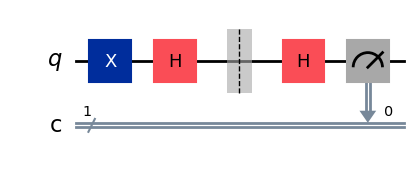

In [11]:
def bb84_example_circuit(alice_bit, alice_basis, bob_basis):
    qc = QuantumCircuit(1, 1)

    # Alice prepares bit value.
    if alice_bit == 1:
        qc.x(0)

    # Alice uses X basis by applying H.
    if alice_basis == 1:
        qc.h(0)

    qc.barrier()

    # Bob measures in X basis by applying H before measurement.
    if bob_basis == 1:
        qc.h(0)

    qc.measure(0, 0)
    return qc

print("Example: Alice sends bit 1 in X basis; Bob measures in X basis")
bb84_example_circuit(1, 1, 1).draw("mpl")


10. Graph key statistics

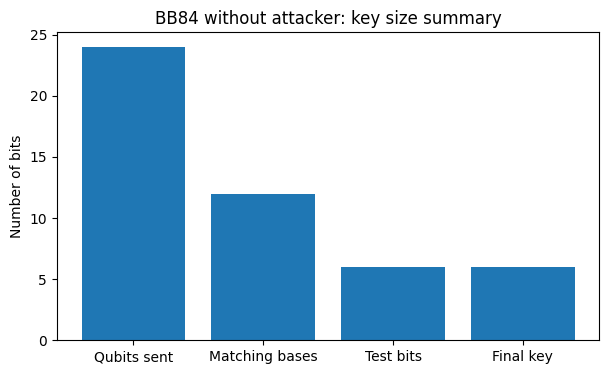

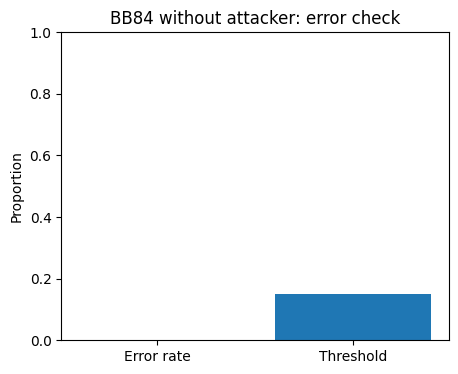

In [12]:
labels = ["Qubits sent", "Matching bases", "Test bits", "Final key"]
values = [N, len(matching_positions), test_size, len(final_alice_key)]

plt.figure(figsize=(7, 4))
plt.bar(labels, values)
plt.title("BB84 without attacker: key size summary")
plt.ylabel("Number of bits")
plt.show()

plt.figure(figsize=(5, 4))
plt.bar(["Error rate", "Threshold"], [error_rate, ATTACK_THRESHOLD])
plt.title("BB84 without attacker: error check")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.show()